In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
plt.style.use("default")


def read_lammps_log(filename):
    """
    Reads a LAMMPS log file and returns a list of DataFrames,
    one per thermo block.
    """
    blocks = []
    with open(filename, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()

        # Detect thermo header
        if line.startswith("Step"):
            header = line.split()
            data = []
            i += 1

            # Read until end of thermo block
            while i < len(lines):
                if lines[i].strip() == "" or lines[i].startswith("Loop time"):
                    break
                data.append(lines[i].split())
                i += 1

            df = pd.DataFrame(data, columns=header).astype(float)
            blocks.append(df)
        i += 1

    return blocks


In [3]:
blocks = read_lammps_log("2ns_log.lammps")

print(f"Found {len(blocks)} thermo blocks.")


Found 3 thermo blocks.


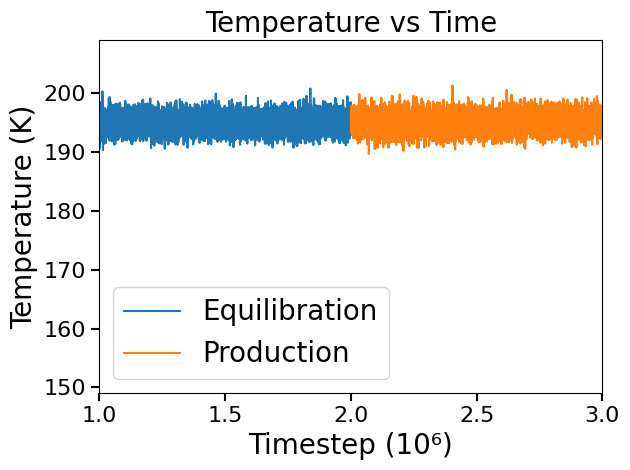

In [4]:
eq = blocks[-2]      # equilibration
prod = blocks[-1]    # production

plt.figure()
plt.plot(eq["Step"], eq["Temp"], label="Equilibration")
plt.plot(prod["Step"], prod["Temp"], label="Production")
plt.xlabel("Timestep (10\u2076)", fontsize=20)
plt.ylabel("Temperature (K)", fontsize=20)

ax = plt.gca()
ax.xaxis.get_offset_text().set_visible(False)

plt.legend(fontsize=20)
plt.title("Temperature vs Time", fontsize=20)
plt.tick_params(axis="both", labelsize=16, length=6, width=1.5)
plt.xlim(999999, 3000000)
plt.ylim(149, 209)
plt.tight_layout()
plt.savefig("figures/2ns/tempvtime.png", format="png", )
plt.show()

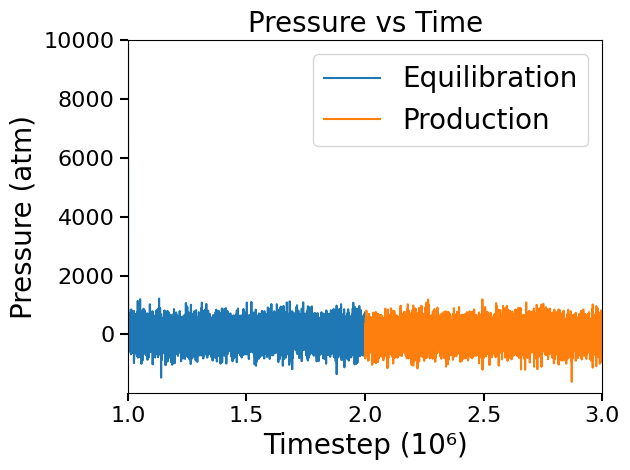

In [5]:
plt.figure()
plt.plot(eq["Step"], eq["Press"], label="Equilibration")
plt.plot(prod["Step"], prod["Press"], label="Production")

plt.xlabel("Timestep (10\u2076)", fontsize=20)
plt.ylabel("Pressure (atm)", fontsize=20)

ax = plt.gca()
ax.xaxis.get_offset_text().set_visible(False)

plt.legend(fontsize=20)
plt.title("Pressure vs Time", fontsize=20)
plt.tick_params(axis="both", labelsize=16, length=6, width=1.5)
plt.xlim(999999, 3000000)
plt.ylim(-1999, 10000)
plt.tight_layout()
plt.savefig("figures/2ns/pvt.png", format="png", )
plt.show()

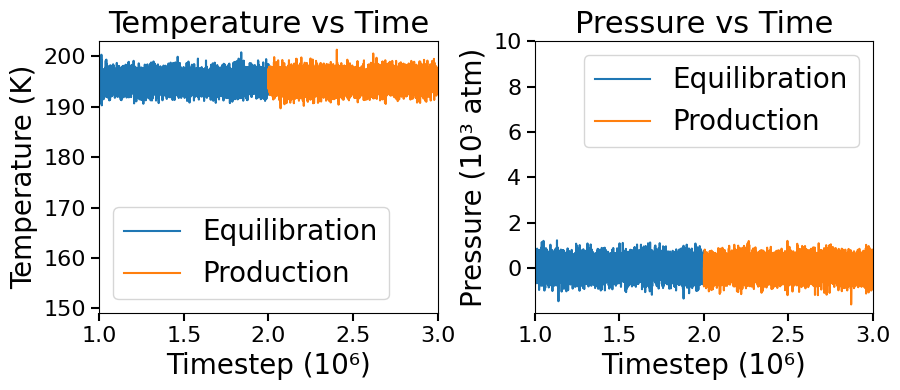

In [6]:
#Temp + pressure subfigs
eq = blocks[-2]      # equilibration
prod = blocks[-1]    # production

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True)

# Temperature (top)
axes[0].plot(eq["Step"], eq["Temp"], label="Equilibration")
axes[0].plot(prod["Step"], prod["Temp"], label="Production")

axes[0].set_xlabel("Timestep (10\u2076)", fontsize=20)
axes[0].set_ylabel("Temperature (K)", fontsize=20)
axes[0].set_title("Temperature vs Time", fontsize=22)
axes[0].tick_params(axis="both", labelsize=16, length=6, width=1.5)
axes[0].legend(fontsize=20)

axes[0].set_xlim(999999, 3000000)
axes[0].set_ylim(149, 203)

axes[0].xaxis.get_offset_text().set_visible(False)

# Pressure
axes[1].plot(eq["Step"], eq["Press"]/1000, label="Equilibration")
axes[1].plot(prod["Step"], prod["Press"]/1000, label="Production")

axes[1].set_xlabel("Timestep (10\u2076)", fontsize=20)
axes[1].set_ylabel("Pressure (10³ atm)", fontsize=20)
axes[1].set_title("Pressure vs Time", fontsize=22)
axes[1].tick_params(axis="both", labelsize=16, length=6, width=1.5)
axes[1].legend(fontsize=20)

axes[1].set_xlim(999999, 3000000)
axes[1].set_ylim(-1.999, 10)

axes[1].xaxis.get_offset_text().set_visible(False)

plt.tight_layout()

plt.savefig("figures/2ns/temp_pressure_vs_time.png", format="png")
plt.show()

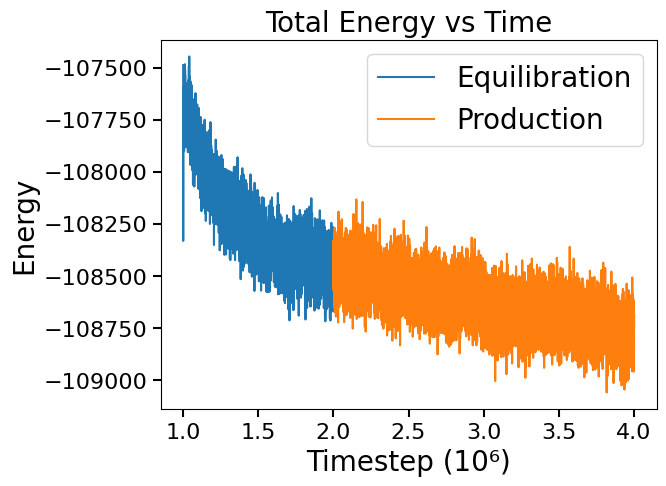

In [7]:
plt.figure()
plt.plot(eq["Step"], eq["TotEng"], label="Equilibration")
plt.plot(prod["Step"], prod["TotEng"], label="Production")
plt.xlabel("Timestep (10\u2076)", fontsize=20)
plt.ylabel("Energy", fontsize=20)

ax = plt.gca()
ax.xaxis.get_offset_text().set_visible(False)

plt.legend(fontsize=20)
plt.title("Total Energy vs Time", fontsize=20)
plt.tick_params(axis="both", labelsize=16, length=6, width=1.5)
plt.savefig("figures/2ns/energyvtime.png", format="png", )


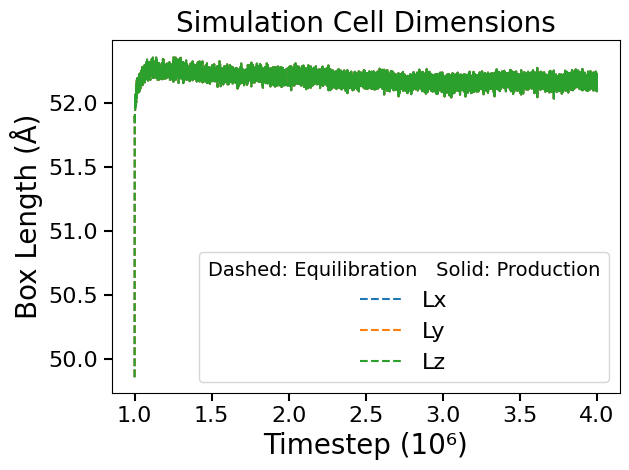

In [8]:
plt.figure()

# Equilibration (dashed)
plt.plot(eq["Step"], eq["Lx"], "C0--", label="Lx")
plt.plot(eq["Step"], eq["Ly"], "C1--", label="Ly")
plt.plot(eq["Step"], eq["Lz"], "C2--", label="Lz")

# Production (solid, same colors)
plt.plot(prod["Step"], prod["Lx"], "C0-")
plt.plot(prod["Step"], prod["Ly"], "C1-")
plt.plot(prod["Step"], prod["Lz"], "C2-")

plt.xlabel("Timestep (10\u2076)", fontsize=20)
plt.ylabel("Box Length (Å)", fontsize=20)

ax = plt.gca()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1e6:.1f}")
)

plt.legend(
    title="Dashed: Equilibration   Solid: Production",
    title_fontsize=14,
    fontsize=16,
    loc="lower right"
)

plt.title("Simulation Cell Dimensions", fontsize=20)
plt.tick_params(axis="both", labelsize=16, length=6, width=1.5)
plt.tight_layout()
plt.savefig("figures/2ns/celldimensions.png", format="png", )
plt.show()



In [9]:
NA = 6.02214076e23  # Avogadro

mass_water = 18.01528   # g/mol
mass_glycerol = 92.09382  # g/mol

total_mass_g = (1000 * mass_water + 1000 * mass_glycerol) / NA


In [10]:
print("EQ columns:", eq.columns.tolist())
print("PROD columns:", prod.columns.tolist())


EQ columns: ['Step', 'Temp', 'Press', 'TotEng', 'PotEng', 'KinEng', 'Volume', 'Lx', 'Ly', 'Lz']
PROD columns: ['Step', 'Temp', 'Press', 'TotEng', 'PotEng', 'KinEng', 'Volume', 'Lx', 'Ly', 'Lz']


In [11]:
eq["Vol"] = eq["Lx"] * eq["Ly"] * eq["Lz"]
prod["Vol"] = prod["Lx"] * prod["Ly"] * prod["Lz"]

print("Volume column created.")
print(eq[["Lx", "Ly", "Lz", "Vol"]].head())


Volume column created.
          Lx         Ly         Lz            Vol
0  49.861346  49.861346  49.861346  123962.976074
1  50.188721  50.188721  50.188721  126420.756564
2  50.711857  50.711857  50.711857  130415.299285
3  51.056837  51.056837  51.056837  133094.993553
4  51.304494  51.304494  51.304494  135041.180553


In [12]:
def compute_density(df, total_mass_g):
    volume_cm3 = df["Vol"] * 1e-24
    return total_mass_g / volume_cm3

In [13]:
eq["Density"] = compute_density(eq, total_mass_g)
prod["Density"] = compute_density(prod, total_mass_g)

print(eq[["Vol", "Density"]].head())


             Vol   Density
0  123962.976074  1.474960
1  126420.756564  1.446285
2  130415.299285  1.401986
3  133094.993553  1.373759
4  135041.180553  1.353961


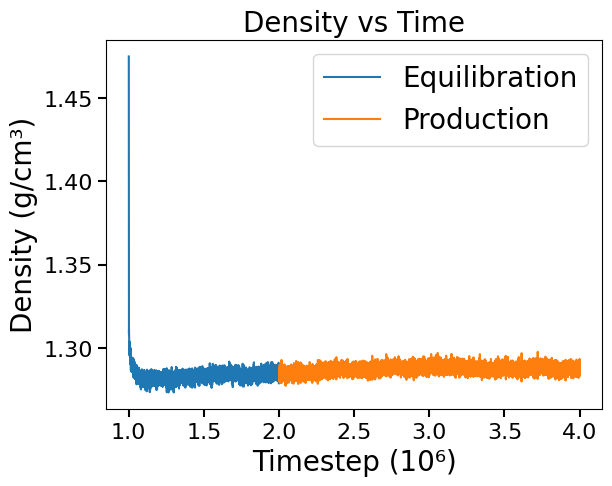

In [14]:
plt.figure()
plt.plot(eq["Step"], eq["Density"], label="Equilibration")
plt.plot(prod["Step"], prod["Density"], label="Production")
plt.xlabel("Timestep (10\u2076)", fontsize=20)
plt.ylabel("Density (g/cm³)", fontsize=20)

ax = plt.gca()
ax.xaxis.get_offset_text().set_visible(False)

plt.legend(fontsize=20)
plt.title("Density vs Time", fontsize=20)
plt.tick_params(axis="both", labelsize=16, length=6, width=1.5)
plt.savefig("figures/2ns/densityvtime.png", format="png", )